In [1]:
import numpy as np
import cv2
import os
import pandas as pd
from PIL import Image
import h5py
import matplotlib.pyplot as plt
from scipy import io
from time import time
import sys
from sklearn.model_selection import train_test_split
from helper_functions.data import write_h5, read_h5_numpy
from typing import List

print(os.getcwd())

n_scale = 7

/tmp/ipykernel_733/2064798447.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


/mnt/c/Users/matte/Dropbox/RESEARCH/PyTorch-Lightning-template/notebooks


In [2]:
def resize_images(
        X : np.ndarray,
        new_dims : List
        ) -> np.ndarray:

    X_resize = np.zeros((
        X.shape[0],
        new_dims[0],
        new_dims[1]),
        np.uint8)

    print('Resizing images ...')
    for i in range(X.shape[0]):
        if i/10000 == i//10000:
            print('   -> Step {} of {}'.format(i,X.shape[0]))
        x = X[i,...]
        if n_scale > 1:
            x = cv2.resize(
                x.astype(np.uint8), 
                dsize=(n_scale*28,n_scale*28), 
                interpolation=cv2.INTER_CUBIC
                )
        X_resize[i,...] = x

    print('Done resizing!')

    return X_resize

In [3]:
fileload = r'../data/fashion-mnist/fashion-mnist_train.csv'

data = pd.read_csv(fileload, low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims).astype(np.uint8)

new_dims = [n_scale*X.shape[1], n_scale*X.shape[2]]

X_resize = resize_images(X, new_dims)

###
X_train, X_val, y_train, y_val = train_test_split(
    X_resize,y,
    test_size=.15,
    shuffle=True,
    random_state=42
)

dict_train = {
    'X' : X_train,
    'y' : y_train,
}

dict_val = {
    'X' : X_val,
    'y' : y_val,
}

verbose = True

write_h5(
    data = dict_train,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    dtype=np.uint8,
    verbose = verbose
    )

write_h5(
    data = dict_val,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_val'.format(n_scale*28,n_scale*28),
    dtype=np.uint8,
    verbose = verbose
    )

Resizing images ...
   -> Step 0 of 2


error: OpenCV(4.9.0) /io/opencv/modules/imgproc/src/resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
fileload = r'../data/fashion-mnist/fashion-mnist_test.csv'

data = pd.read_csv(fileload, low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)

X_resize = resize_images(X, new_dims)

###
dict_test = {
    'X' : X_resize,
    'y' : y,
}

verbose = True

write_h5(
    data = dict_test,
    filename='../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    dtype=np.int8,
    verbose = verbose
    )



Resizing images ...
   -> Step 0 of 10000
Done resizing!
Processing key: X, dims: (10000, 196, 196), size: 384.16MB
Processing key: y, dims: (10000, 1), size: 0.00MB
 -> DonE! Elapsed time: 1.502s, final size: 101.39MB


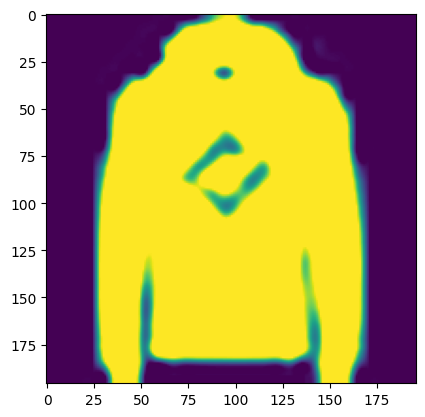

[2]


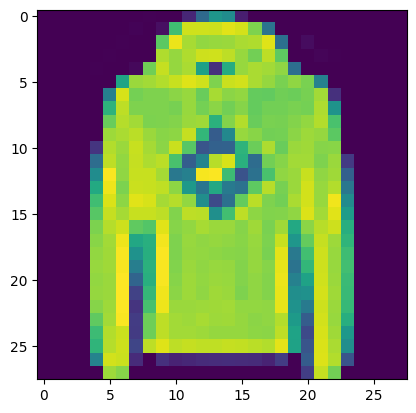

In [ ]:
data_load = read_h5_numpy(
    '../data/fashion-mnist/fashion-mnist_{}x{}_test.h5'.format(new_dims[0],new_dims[1])
)

ind = 1000
# ind = 1001

plt.imshow(data_load['X'][ind,:,:])
plt.show()

paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

data = pd.read_csv(paths_load[1], low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)
print(y[ind])

plt.imshow(X[ind,:,:])
plt.show()